In [1]:
import matplotlib.pyplot as plt
import numpy as np

from dissipationIFR import interactive, tools, plots, utilities
import pathlib
import importlib

import pandas as pd
import xarray as xr

# 1. Loading dataset with nice interactive glider selection

In [2]:
data_dir = pathlib.Path("/Users/u302042/Desktop/Master_thesis/Data/Glider/")

In [3]:
selected_glider = interactive.interactive_glider_selection(data_dir)

Dropdown(description='Select Glider:', options=('005', '012', '014', '016', '101', '102', '103', '104'), value…

Dropdown(description='Select Mission:', options=('06/08 (dives: 386)', '11/08 (dives: 486)', '08/09 (dives: 46…

Button(description='Confirm Selection', style=ButtonStyle())

In [4]:
selected_glider['path']

'/Users/u302042/Desktop/Master_thesis/Data/Glider/005/20080606/'

In [5]:
filename = "all_data_OG1.nc"
ds = xr.open_dataset(selected_glider['path'] + filename)

# 2. Calculate buoyancy frequency
I am using two different approaches:
1. Adiabatically sorted $N^2$, following Millard (1990)
2. The usual approach of calculating $N^2$

Both approaches are compared against the `gsw` implementation of buoyancy frequency (`gsw.Nsquared`).

In [6]:
profile_number = ds['PROFILE_NUMBER'].values
press = ds['PRES'].values
temp = ds['TEMP'].values
psal = ds['PSAL'].values
lat = ds['LATITUDE'].values
lon = ds['LONGITUDE'].values

xi = ds['PROFILE_NUMBER'].max()
yi_bins = 5  # pressure bin width/resolution, matching your example call

## 2.1 Adiabatically sorted $N^2$ (Millard, 1990)

$$
N^2 = \frac{g^2}{V(S, T, p)^2} \left[ \frac{\delta(S_1, \theta(S_1, T_1, p_1, p), p) - \delta(S_2, \theta(S_2, T_2, p_2, p), p)}{p_1 - p_2} \right]
$$

where $\delta$ denotes the specific volume anomaly, $\theta$ is potential temperature, $V$ is specific volume, and $p_1$, $p_2$ are the pressures of two vertically adjacent samples referenced to a common pressure $p$.

In [7]:
plev_list = [5, 10, 15]
n_list = [1, 3, 5]
sorted_profiles = {}   # plev -> (median_N_profile, yi_coords)
sorted_all = {}       # plev -> n_sorted
print("Computing sorted N for each plev...")
for plev in plev_list:
    n_sorted = tools.calc_n_sorted(
        profile_number, press, temp, psal, lat, lon, plev=plev
    )
    sorted_all[plev] = n_sorted
    grid_sorted, xi_grid, yi_grid = utilities.construct_2dgrid(
        profile_number, press, n_sorted, xi=xi, yi=yi_bins, agg="median"
    )
    sorted_profiles[plev] = (grid_sorted.flatten(), yi_grid.flatten())

Computing sorted N for each plev...


100%|██████████| 770/770 [00:10<00:00, 70.08it/s] 


## 2.2 Usual approach

$$
N^2 = -\frac{g}{\rho} \frac{\partial \rho}{\partial z}
$$

where $\rho$ is in-situ (or potential) density and $z$ is depth.

In [8]:
import importlib
importlib.reload(tools)

unsorted_profiles = {} # n   -> (median_N_profile, yi_coords)
unsorted_all = {}
print("Computing unsorted N for each n...")
for n_pts in n_list:
    n_unsorted = tools.calc_n(press, temp, psal, lat, lon, n=n_pts)
    unsorted_all[n_pts] = n_unsorted
    grid_unsorted, xi_grid, yi_grid = utilities.construct_2dgrid(
        profile_number, press, n_unsorted, xi=xi, yi=yi_bins, agg="median"
    )
    unsorted_profiles[n_pts] = (grid_unsorted.flatten(), yi_grid.flatten())

Computing unsorted N for each n...


## Testing

I tested both functions by varying:
- **Adiabatic sorting approach**: the pressure level spacing (`plev = p1 - p2`)
- **Usual approach**: the number of samples taken into account for the density gradient

All results were compared against the `gsw` approach of calculating $N^2$.

In [10]:
import gsw
SA = gsw.SA_from_SP(psal, press, lon, lat)
CT = gsw.CT_from_t(SA, temp, press)

n_gsw = np.sqrt(gsw.Nsquared(SA, CT, press, lat)[0])  # returns (N², p_mid)
grid_gsw, xi_grid, yi_grid = utilities.construct_2dgrid(
    profile_number[:-1], press[:-1], n_gsw, xi=xi, yi=yi_bins, agg="median"
)

/Users/u302042/miniconda3/envs/dissipationIFR/lib/python3.14/site-packages/gsw/stability.py:86: RuntimeWarning: divide by zero encountered in divide
  N2 = ((g_local**2) / (specvol_mid * db_to_pa * dp))
/var/folders/z8/9w8hm9jj0xb3r12hb67dm3vh0000gq/T/ipykernel_50757/1199203084.py:5: RuntimeWarning: invalid value encountered in sqrt
  n_gsw = np.sqrt(gsw.Nsquared(SA, CT, press, lat)[0])  # returns (N², p_mid)


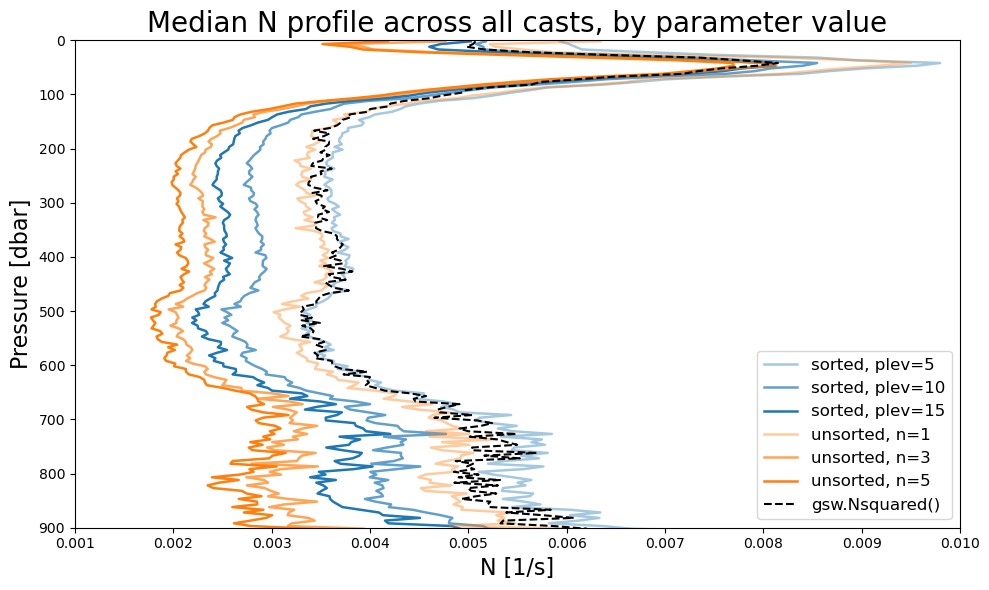

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

blue_alphas = np.linspace(0.4, 1.0, len(plev_list))
orange_alphas = np.linspace(0.4, 1.0, len(n_list))

for alpha, plev in zip(blue_alphas, plev_list):
    profile, yi_grid = sorted_profiles[plev]
    ax.plot(profile, yi_grid, color="tab:blue", alpha=alpha, lw=1.8,
             label=f"sorted, plev={plev}")

for alpha, n_pts in zip(orange_alphas, n_list):
    profile, yi_grid = unsorted_profiles[n_pts]
    ax.plot(profile, yi_grid, color="tab:orange", alpha=alpha, lw=1.8,
             label=f"unsorted, n={n_pts}")
ax.plot(grid_gsw.flatten(), yi_grid.flatten(), color="black", lw=1.5, label="gsw.Nsquared()", ls="--")

ax.invert_yaxis()
ax.set_xlabel("N [1/s]", fontsize=16)
ax.set_ylabel("Pressure [dbar]", fontsize=16)
ax.set_title("Median N profile across all casts, by parameter value", fontsize=20)
ax.legend(fontsize=12, loc="lower right")
ax.set_ylim(900, 0)  # Set y-axis limits to focus on the upper 200 dbar
ax.set_xlim(0.001, 0.01)  # Set x-axis limits to focus on the range of N values
fig.tight_layout()
plt.show()

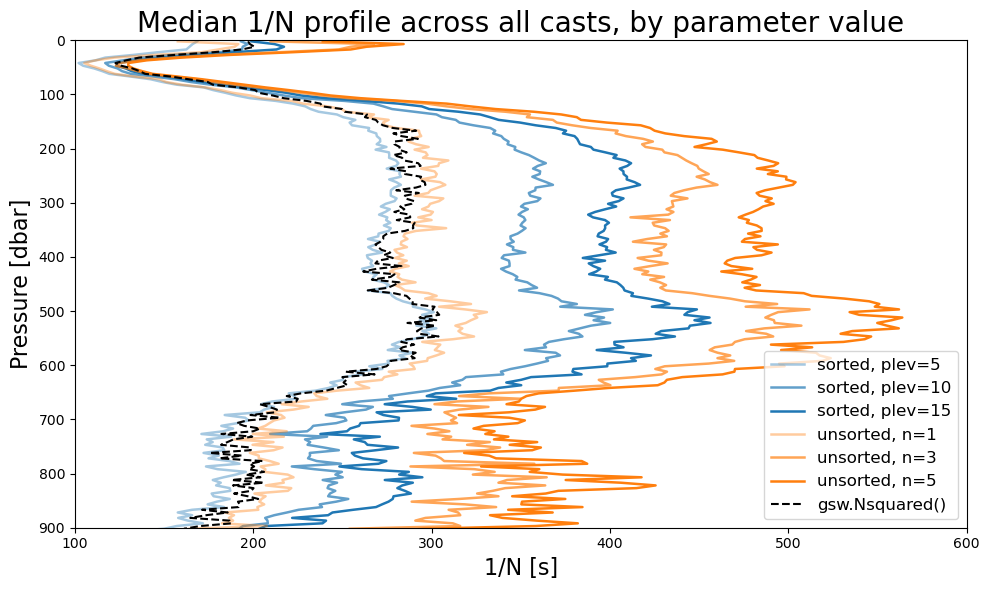

In [12]:
### Now plot 1/N for all the different methods, to see if they converge to the same value at depth
fig, ax = plt.subplots(figsize=(10, 6))

blue_alphas = np.linspace(0.4, 1.0, len(plev_list))
orange_alphas = np.linspace(0.4, 1.0, len(n_list))

for alpha, plev in zip(blue_alphas, plev_list):
    profile, yi_grid = sorted_profiles[plev]
    ax.plot(1/profile, yi_grid, color="tab:blue", alpha=alpha, lw=1.8,
             label=f"sorted, plev={plev}")
for alpha, n_pts in zip(orange_alphas, n_list):
    profile, yi_grid = unsorted_profiles[n_pts]
    ax.plot(1/profile, yi_grid, color="tab:orange", alpha=alpha, lw=1.8,
             label=f"unsorted, n={n_pts}")
ax.plot(1/grid_gsw.flatten(), yi_grid.flatten(), color="black", lw=1.5, label="gsw.Nsquared()", ls="--")
ax.invert_yaxis()
ax.set_xlabel("1/N [s]", fontsize=16)
ax.set_ylabel("Pressure [dbar]", fontsize=16)
ax.set_title("Median 1/N profile across all casts, by parameter value", fontsize=20)
ax.legend(fontsize=12, loc="lower right")
ax.set_ylim(900, 0)  # Set y-axis limits to focus on the upper 200 dbar
ax.set_xlim(100, 600)  # Set x-axis limits to focus on the range of 1/N values
fig.tight_layout()

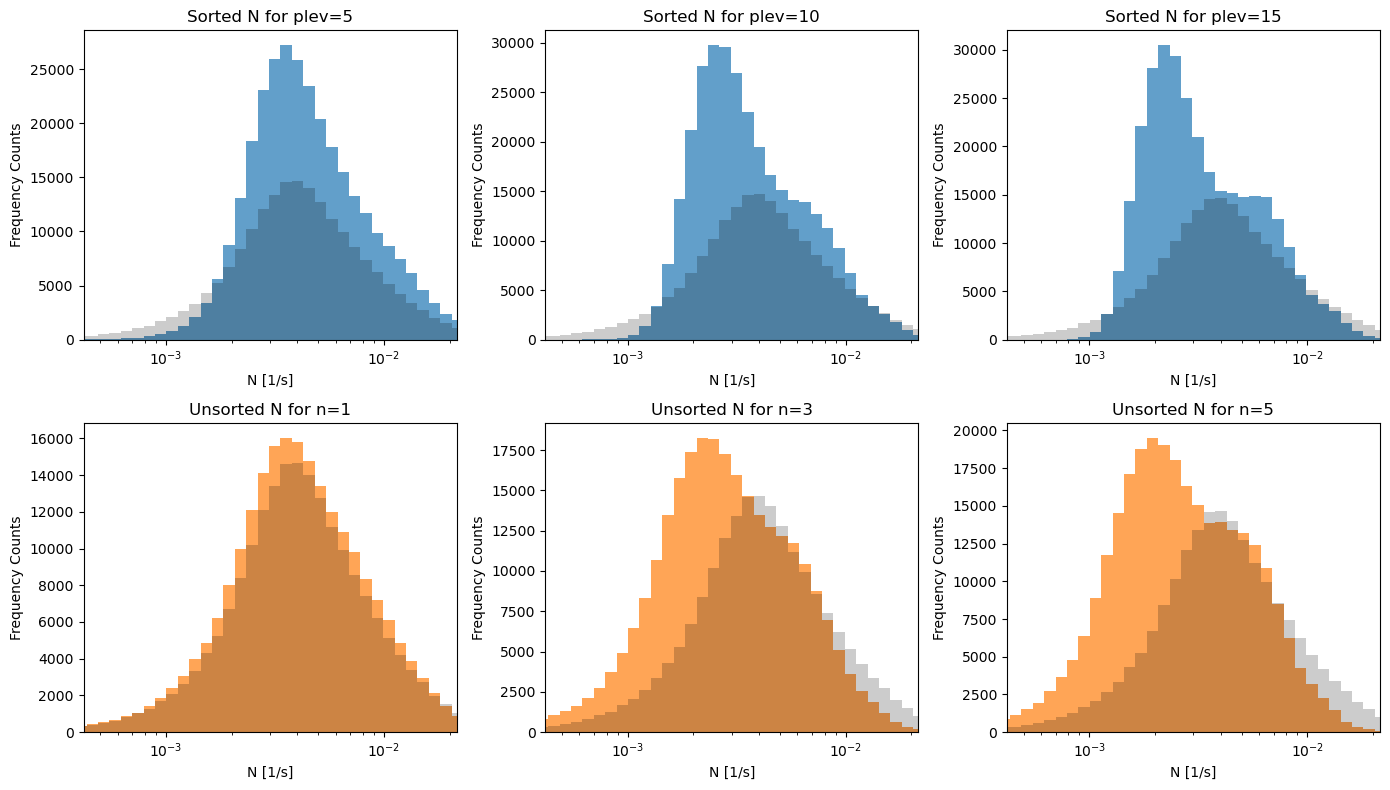

In [13]:
### plot histograms of N for each method, to see if they converge to the same distribution
fig, axs = plt.subplots(2, 3, figsize=(14, 8))
axs = axs.flatten()  # Flatten the 2D array of axes for easier indexing

n_bins = 100

# --- common log-spaced bins across all subplots (raw N values, not log10-transformed) ---
n_gsw = n_gsw[np.isfinite(n_gsw) & (n_gsw > 0)]

sorted_vals = {}
for plev in plev_list:
    data = sorted_all[plev]
    sorted_vals[plev] = data[np.isfinite(data) & (data > 0)]

unsorted_vals = {}
for n_pts in n_list:
    data = unsorted_all[n_pts]
    unsorted_vals[n_pts] = data[np.isfinite(data) & (data > 0)]

all_vals = np.concatenate(
    list(sorted_vals.values()) + list(unsorted_vals.values()) + [n_gsw]
)
log_bins = np.logspace(np.log10(all_vals.min()), np.log10(all_vals.max()), n_bins)

# percentile-based xlim so outliers don't blow out the axis (still in raw, not log, units)
xmin = np.nanpercentile(all_vals, 0.5)
xmax = np.nanpercentile(all_vals, 99.5)

for i, plev in enumerate(plev_list):
    axs[i].hist(sorted_vals[plev], bins=log_bins, color='tab:blue', alpha=0.7,)
    axs[i].hist(n_gsw, bins=log_bins, color='black', alpha=0.2)
    axs[i].set_xscale('log')
    axs[i].set_xlim(xmin, xmax)
    axs[i].set_xlabel('N [1/s]')
    axs[i].set_ylabel('Frequency Counts')
    axs[i].set_title(f"Sorted N for plev={plev}")

for i, n_pts in enumerate(n_list):
    ax = axs[i + len(plev_list)]
    ax.hist(unsorted_vals[n_pts], bins=log_bins, color='tab:orange', alpha=0.7)
    ax.hist(n_gsw, bins=log_bins, color='black', alpha=0.2)
    ax.set_xscale('log')
    ax.set_xlim(xmin, xmax)
    ax.set_xlabel('N [1/s]')
    ax.set_ylabel('Frequency Counts')
    ax.set_title(f"Unsorted N for n={n_pts}")

plt.tight_layout()

In [14]:
profile_number = ds['PROFILE_NUMBER'].values
press = ds['PRES'].values
temp = ds['TEMP'].values
psal = ds['PSAL'].values
lat = ds['LATITUDE'].values
lon = ds['LONGITUDE'].values

xi = ds['PROFILE_NUMBER'].max()
yi_bins = 5  # pressure bin width/resolution, matching your example call


plev = 5
n_sorted = tools.calc_n_sorted(profile_number, press, temp, psal, lat, lon, plev=plev)
n = 1
n_unsorted = tools.calc_n(press, temp, psal, lat, lon, n=n)

100%|██████████| 770/770 [00:10<00:00, 74.87it/s] 


In [15]:
ds['N_SORTED'] = (('N_MEASUREMENTS'), n_sorted)
ds['N'] = (('N_MEASUREMENTS'), n_unsorted)

w_water = ds['GLIDER_VERT_VELO_MODEL'].values - ds['W_MEAS'].values
ds['W_WATER'] = (('N_MEASUREMENTS'), w_water)

In [16]:
gridded_ds = utilities.grid_dataset(ds, variables = ['W_WATER', 'N', 'N_SORTED'], bin_variable = 'TIME', res=None)

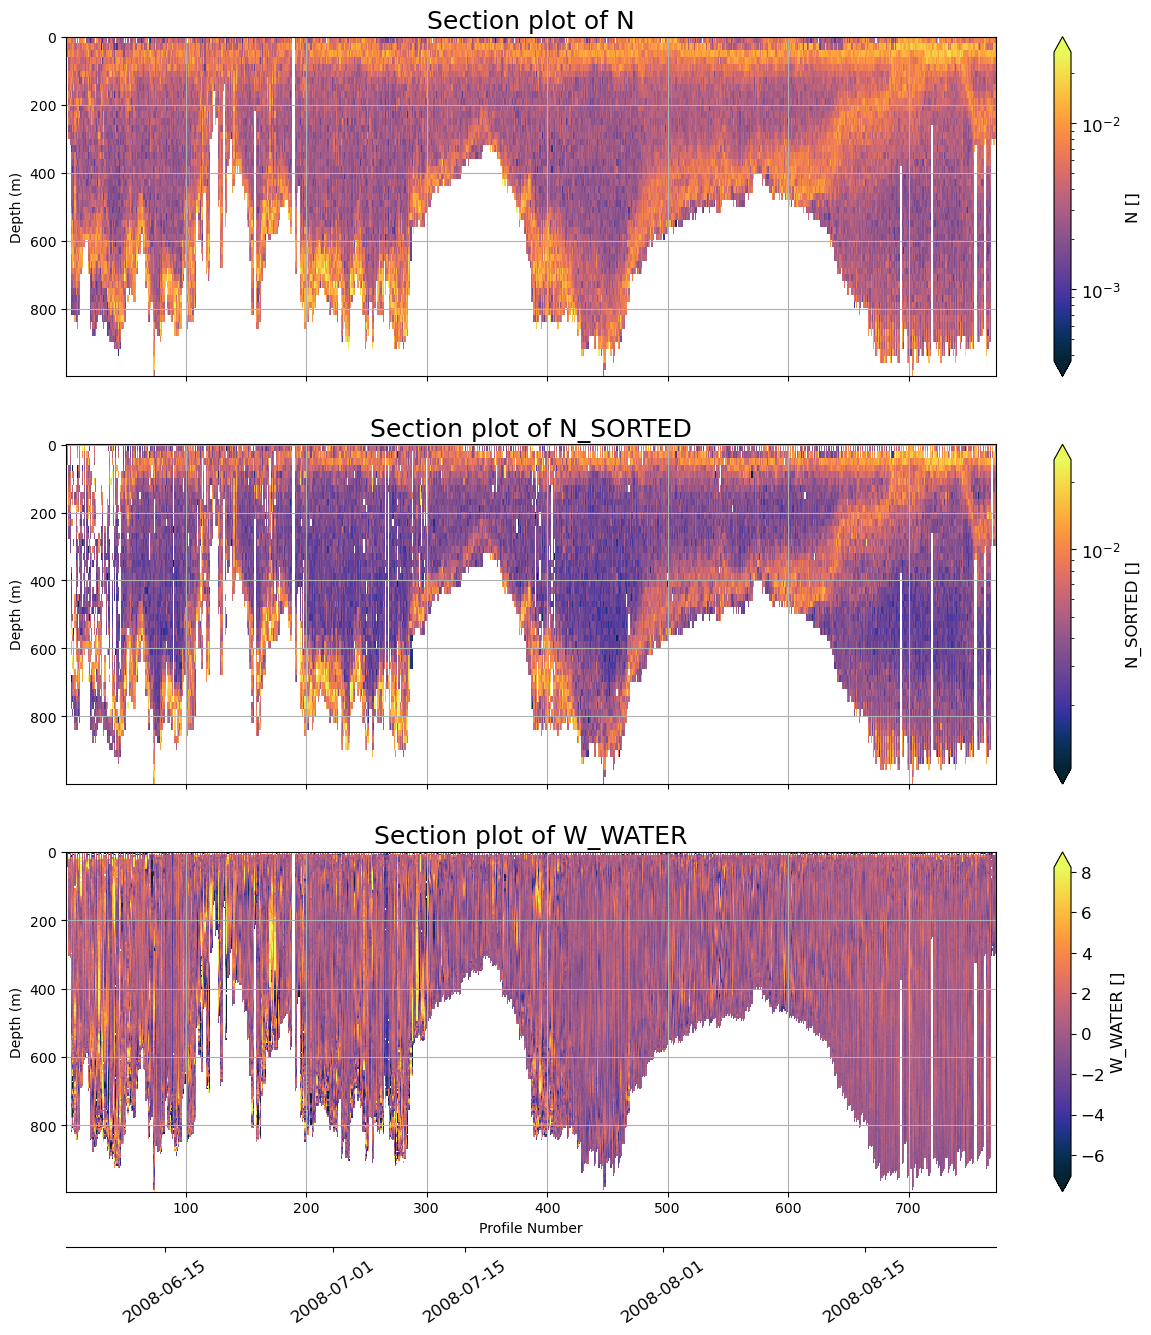

In [17]:
from cmocean import cm as cmo
fig, ax = plt.subplots(3, 1, figsize=(15, 15))
ax[0],_,_ = plots.plot_section(gridded_ds, var='N', log_scale=True, cmap=cmo.thermal, v_res = 20, ax=ax[0], show_time_axis = False)
ax[1],_,_ = plots.plot_section(gridded_ds, var='N_SORTED', log_scale=True, cmap=cmo.thermal, v_res = 20, ax=ax[1], show_time_axis = False)
ax[2],_,_ = plots.plot_section(gridded_ds, var='W_WATER', cmap=cmo.thermal, v_res = 5, ax=ax[2])
## delete x-axis for the first two subplots
for ax in ax[:2]:
    ax.set_xlabel('')
    ax.set_xticklabels([])
plt.show()

# 3. Calculate velocity scale

I am again using two different approaches:
1. A highpass Butterworth filter with a constant cutoff period
2. An adaptive highpass Butterworth filter, with the cutoff period set to $1/N$, computed within a set window

For the adaptive approach, the whole profile is filtered separately for each window, using the mean $1/N$ value within that window as the cutoff period. However, only the filtered values corresponding to that particular window are kept from each run. Effectively, this means the filter length changes for each window, while each window's filtered values are still derived from a filter applied to the entire profile.

In [19]:
importlib.reload(tools)
w_water_hp_adaptive = tools.highpass_butterworth_time(gridded_ds['W_WATER'].values, gridded_ds['TIME'].values, gridded_ds['PROFILE_NUMBER'].values, cutoff_period=1/(gridded_ds['N'].values), order=4, max_interval=40, adaptive_window=200)
w_water_hp_330 = tools.highpass_butterworth_time(gridded_ds['W_WATER'].values, gridded_ds['TIME'].values, gridded_ds['PROFILE_NUMBER'].values, cutoff_period=330, order=4, max_interval=40)
gridded_ds['W_WATER_HP_ADAPTIVE'] = (('N_MEASUREMENTS'), w_water_hp_adaptive)
gridded_ds['W_WATER_HP_330'] = (('N_MEASUREMENTS'), w_water_hp_330)

Filtering:   0%|          | 0/770 [00:00<?, ?it/s]/Users/u302042/Desktop/DissipationIFR/dissipationIFR/dissipationIFR/tools.py:335: RuntimeWarning: Mean of empty slice
  win_cutoff = np.nanmean(cutoff_sub[win_start:win_end])
Filtering: 100%|██████████| 770/770 [00:00<00:00, 3054.27it/s]


The running RMS is calculated over the highpass-filtered profiles to obtain the velocity scale $\sigma_w$.

In [20]:
velocity_rms_adaptive = tools.rolling_rms(gridded_ds['W_WATER_HP_ADAPTIVE'].values, gridded_ds['TIME'].values, gridded_ds['PROFILE_NUMBER'].values, window_size_seconds=100)
velocity_rms_330 = tools.rolling_rms(gridded_ds['W_WATER_HP_330'].values, gridded_ds['TIME'].values, gridded_ds['PROFILE_NUMBER'].values, window_size_seconds=100)
gridded_ds['VELOCITY_RMS_ADAPTIVE'] = (('N_MEASUREMENTS'), velocity_rms_adaptive)
gridded_ds['VELOCITY_RMS_330'] = (('N_MEASUREMENTS'), velocity_rms_330)

Computing RMS: 100%|██████████| 770/770 [00:00<00:00, 4151.15it/s]


In [23]:
importlib.reload(tools)
epsilon_adaptive = tools.calc_epsilon(gridded_ds['VELOCITY_RMS_ADAPTIVE'].values/100, gridded_ds['N'].values)
epsilon_330 = tools.calc_epsilon(gridded_ds['VELOCITY_RMS_330'].values/100, gridded_ds['N'].values)
gridded_ds['EPSILON_ADAPTIVE'] = (('N_MEASUREMENTS'), epsilon_adaptive)
gridded_ds['EPSILON_330'] = (('N_MEASUREMENTS'), epsilon_330)

Profiles and sections are compared between the two approaches.

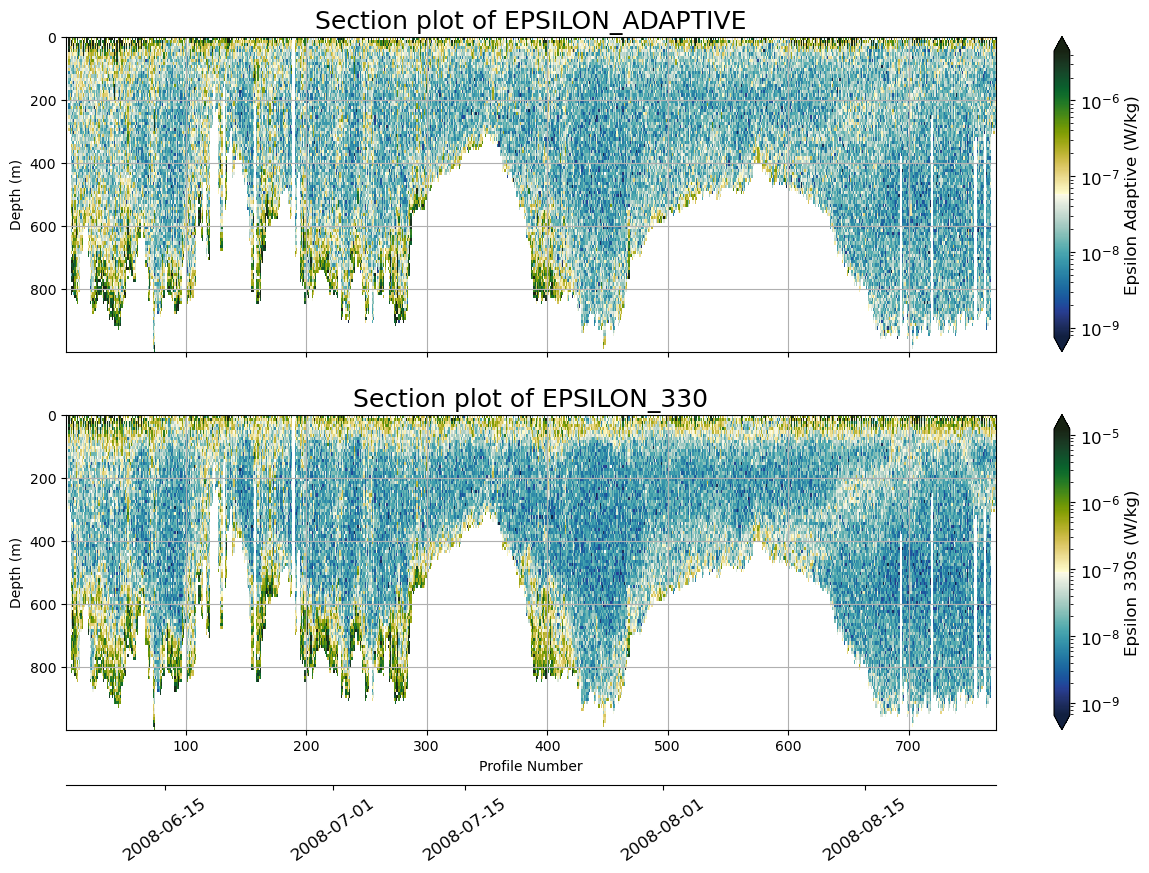

In [24]:
importlib.reload(plots)
fig, ax = plt.subplots(2, 1, figsize=(15, 9))
ax[0],cbar0,_ = plots.plot_section(gridded_ds, var='EPSILON_ADAPTIVE', cmap=cmo.delta, v_res = 10, log_scale=True,show_time_axis=False, ax=ax[0])
ax[1],cbar1,_ = plots.plot_section(gridded_ds, var='EPSILON_330', cmap=cmo.delta, v_res = 10, log_scale=True, ax=ax[1])
ax[0].set_xlabel('')
ax[0].set_xticklabels([])
cbar0.set_label('Epsilon Adaptive (W/kg)')
cbar1.set_label('Epsilon 330s (W/kg)')
plt.show()

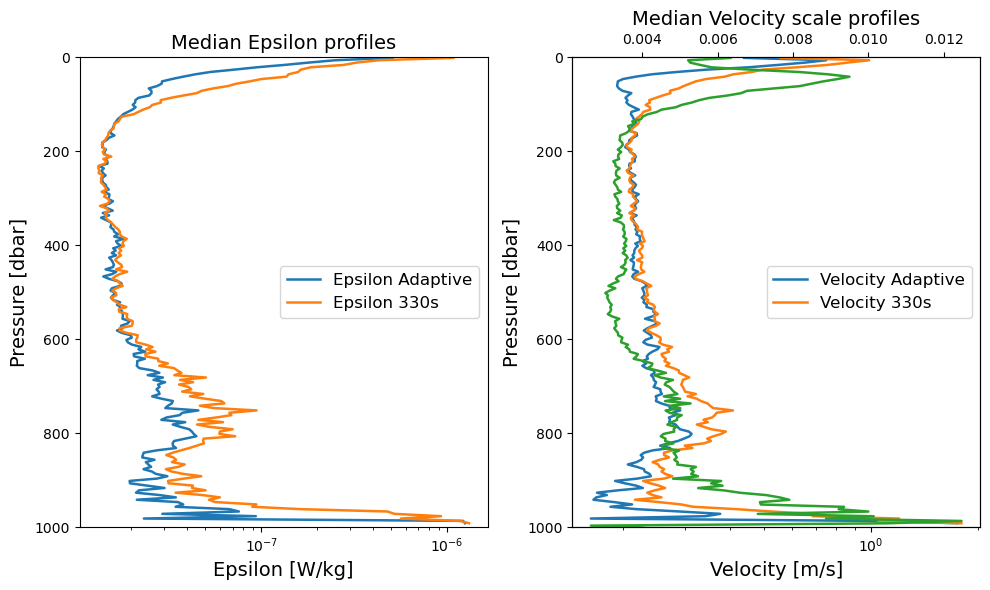

In [63]:
# plot the median epsilon profile for both methods, to see if they converge to the same value at depth
grid_adaptive_eps, xi_grid, yi_grid = utilities.construct_2dgrid(
    gridded_ds['PROFILE_NUMBER'].values, gridded_ds['DEPTH'].values, gridded_ds['EPSILON_ADAPTIVE'].values, xi=xi, yi=yi_bins, agg="median"
)
grid_330_eps, xi_grid, yi_grid = utilities.construct_2dgrid(
    gridded_ds['PROFILE_NUMBER'].values, gridded_ds['DEPTH'].values, gridded_ds['EPSILON_330'].values, xi=xi, yi=yi_bins, agg="median"
)
grid_adaptive_vel, xi_grid, yi_grid = utilities.construct_2dgrid(
    gridded_ds['PROFILE_NUMBER'].values, gridded_ds['DEPTH'].values, gridded_ds['VELOCITY_RMS_ADAPTIVE'].values, xi=xi, yi=yi_bins, agg="median"
)

grid_330_vel, xi_grid, yi_grid = utilities.construct_2dgrid(
    gridded_ds['PROFILE_NUMBER'].values, gridded_ds['DEPTH'].values, gridded_ds['VELOCITY_RMS_330'].values, xi=xi, yi=yi_bins, agg="median"
)

fig, axes = plt.subplots(1, 2, figsize=(10, 6))

axes[0].plot(grid_adaptive_eps.flatten(), yi_grid.flatten(), color="tab:blue", lw=1.8, label="Epsilon Adaptive")
axes[0].plot(grid_330_eps.flatten(), yi_grid.flatten(), color="tab:orange", lw=1.8, label="Epsilon 330s")
axes[0].invert_yaxis()
axes[0].set_xlabel("Epsilon [W/kg]", fontsize=14)
axes[0].set_ylabel("Pressure [dbar]", fontsize=14)
axes[0].set_title("Median Epsilon profiles", fontsize=14)

axes[1].plot(grid_adaptive_vel.flatten(), yi_grid.flatten(), color="tab:blue", lw=1.8, label="Velocity Adaptive")
axes[1].plot(grid_330_vel.flatten(), yi_grid.flatten(), color="tab:orange", lw=1.8, label="Velocity 330s")
axes[1].invert_yaxis()
axes[1].set_xlabel("Velocity [m/s]", fontsize=14)
axes[1].set_ylabel("Pressure [dbar]", fontsize=14)
axes[1].set_title("Median Velocity scale profiles", fontsize=14)
ax_twin = axes[1].twiny()
x, y = unsorted_profiles[1]
ax_twin.plot(x,y, color="tab:green", lw=1.8, label="N values")

for ax in axes:
    ax.set_ylim(1000, 0)
    ax.legend(fontsize=12)
    ax.set_xscale('log')

plt.tight_layout()
plt.show()
